# Notebook 03: Head Diagnostics — Are These Actually Induction Heads?

Notebooks 01–02 identified heads that are *causally important* for induction
(patching and ablation). But that doesn't prove they're doing induction —
maybe they play a supporting role.

This notebook checks: **do these heads actually attend to the matching token
in the first half?** That's the defining behavior of an induction head.

We'll:
1. Extract attention patterns from the top heads
2. Compute an "induction score" (attention to the correct source position)
3. Visualize attention heatmaps for the top heads

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

from src.data import make_induction_tokens

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained('gpt2-small', device=device)

N_CTX_HALF = 50
BATCH = 30

tokens = make_induction_tokens(
    batch=BATCH,
    n_ctx_half=N_CTX_HALF,
    bos_token_id=model.tokenizer.bos_token_id,
    seed=42,
).to(device)

# Run model and cache everything
logits, cache = model.run_with_cache(tokens)
print(f'Cache has {len(cache)} entries')
print(f'GPU: {torch.cuda.get_device_name(0)}')

## Step 1: Compute induction scores for ALL heads

For each head, at each destination position `t` in the second half,
the "induction source" is the position in the first half where the
same token appeared. In our construction, that's `t - N_CTX_HALF`.

An induction head should put high attention weight on that source position.

**Induction score** = mean attention to the correct source position,
averaged over all second-half positions and all batch elements.

Random baseline: `1 / seq_len ≈ 0.01`

In [3]:
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
seq_len = tokens.shape[1]

induction_scores = torch.zeros(n_layers, n_heads)

for layer in range(n_layers):
    # Attention pattern: [batch, n_heads, dest_pos, src_pos]
    attn = cache[f'blocks.{layer}.attn.hook_pattern']

    for head in range(n_heads):
        # For each destination in the second half, check attention to matching source
        score = 0.0
        count = 0
        for t in range(1 + N_CTX_HALF, seq_len):  # second half positions
            src = t - N_CTX_HALF  # matching position in first half
            # Average attention to matching source across batch
            score += attn[:, head, t, src].mean().item()
            count += 1
        induction_scores[layer, head] = score / count

random_baseline = 1.0 / seq_len
print(f'Random baseline attention: {random_baseline:.4f}')
print(f'\nTop 10 heads by induction score:')

flat_idx = induction_scores.flatten().argsort(descending=True)[:10]
for idx in flat_idx:
    layer = idx.item() // n_heads
    head = idx.item() % n_heads
    print(f'  L{layer}H{head}: induction score = {induction_scores[layer, head]:.4f}'
          f'  ({induction_scores[layer, head] / random_baseline:.1f}x baseline)')

Random baseline attention: 0.0099

Top 10 heads by induction score:
  L3H0: induction score = 0.6651  (67.2x baseline)
  L0H5: induction score = 0.6440  (65.0x baseline)
  L0H1: induction score = 0.2649  (26.8x baseline)
  L1H11: induction score = 0.0841  (8.5x baseline)
  L0H10: induction score = 0.0595  (6.0x baseline)
  L5H10: induction score = 0.0549  (5.5x baseline)
  L7H1: induction score = 0.0504  (5.1x baseline)
  L7H2: induction score = 0.0375  (3.8x baseline)
  L1H6: induction score = 0.0317  (3.2x baseline)
  L8H1: induction score = 0.0279  (2.8x baseline)


## Step 2: Induction score heatmap

Visualize all 144 heads — which ones have high induction scores?

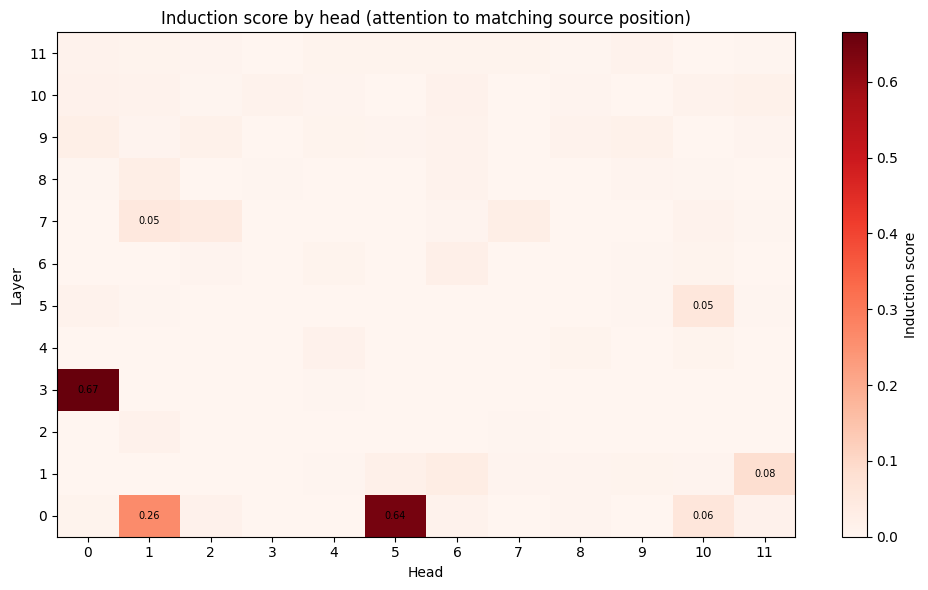

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

data = induction_scores.numpy()
im = ax.imshow(data, aspect='auto', cmap='Reds', origin='lower')

ax.set_xlabel('Head')
ax.set_ylabel('Layer')
ax.set_title('Induction score by head (attention to matching source position)')
ax.set_xticks(range(n_heads))
ax.set_yticks(range(n_layers))

# Annotate strong values
for i in range(n_layers):
    for j in range(n_heads):
        if data[i, j] > 0.05:
            ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.colorbar(im, ax=ax, label='Induction score')
plt.tight_layout()
plt.savefig('../results/figures/fig4a_induction_scores.png', dpi=150)
plt.show()

## Step 3: Compare induction scores vs ablation contributions

Do the heads with high induction scores (attend to the right position)
match the heads with high ablation contributions (causally important)?

If yes, it confirms: these heads matter *because* they're doing induction.

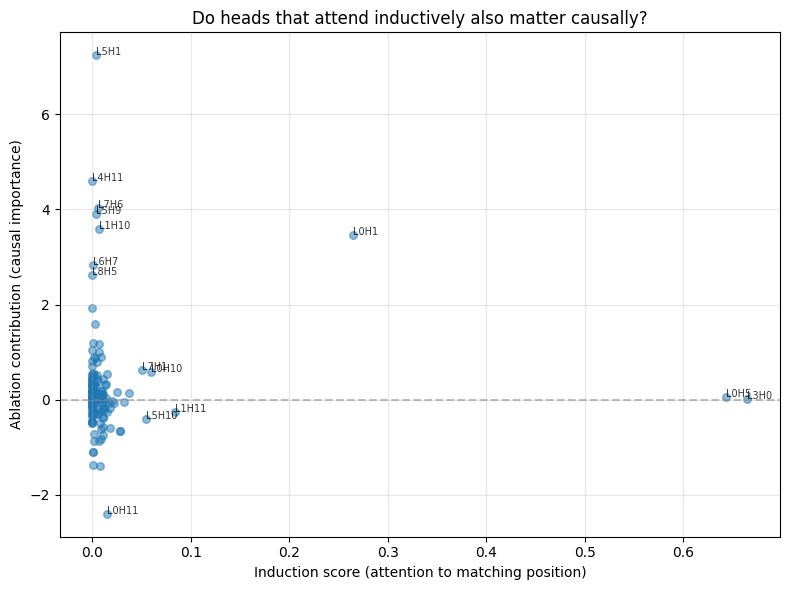

Correlation between induction score and ablation contribution: 0.027


In [5]:
# Load ablation contributions from notebook 02
from src.metrics import induction_positions_and_targets, logit_diff
from src.ablation import compute_ablation_effects

eval_positions, eval_targets = induction_positions_and_targets(tokens.cpu(), N_CTX_HALF)
eval_positions = eval_positions.to(device)
eval_targets = eval_targets.to(device)

def metric_fn(logits):
    return logit_diff(logits, eval_positions, eval_targets)

clean_results = compute_ablation_effects(model, tokens, metric_fn)

# Build contribution grid
contrib_grid = torch.zeros(n_layers, n_heads)
for (layer, head), contrib in clean_results['contributions'].items():
    contrib_grid[layer, head] = contrib

# Scatter plot: induction score vs ablation contribution
fig, ax = plt.subplots(figsize=(8, 6))

x = induction_scores.flatten().numpy()
y = contrib_grid.flatten().numpy()

ax.scatter(x, y, alpha=0.5, s=30)

# Label notable heads
for layer in range(n_layers):
    for head in range(n_heads):
        if induction_scores[layer, head] > 0.05 or abs(contrib_grid[layer, head]) > 2.0:
            ax.annotate(f'L{layer}H{head}',
                       (induction_scores[layer, head].item(), contrib_grid[layer, head].item()),
                       fontsize=7, alpha=0.8)

ax.set_xlabel('Induction score (attention to matching position)')
ax.set_ylabel('Ablation contribution (causal importance)')
ax.set_title('Do heads that attend inductively also matter causally?')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/fig4b_score_vs_contribution.png', dpi=150)
plt.show()

# Correlation
corr = np.corrcoef(x, y)[0, 1]
print(f'Correlation between induction score and ablation contribution: {corr:.3f}')

## Step 4: Attention heatmaps for top heads

The most convincing visual: show the actual attention pattern for 1–2 heads
on a single example. For an induction head, you should see a clear diagonal
stripe — each second-half position attending to its matching first-half position.

Plotting attention patterns for: ['L3H0', 'L0H5', 'L0H1', 'L1H11']


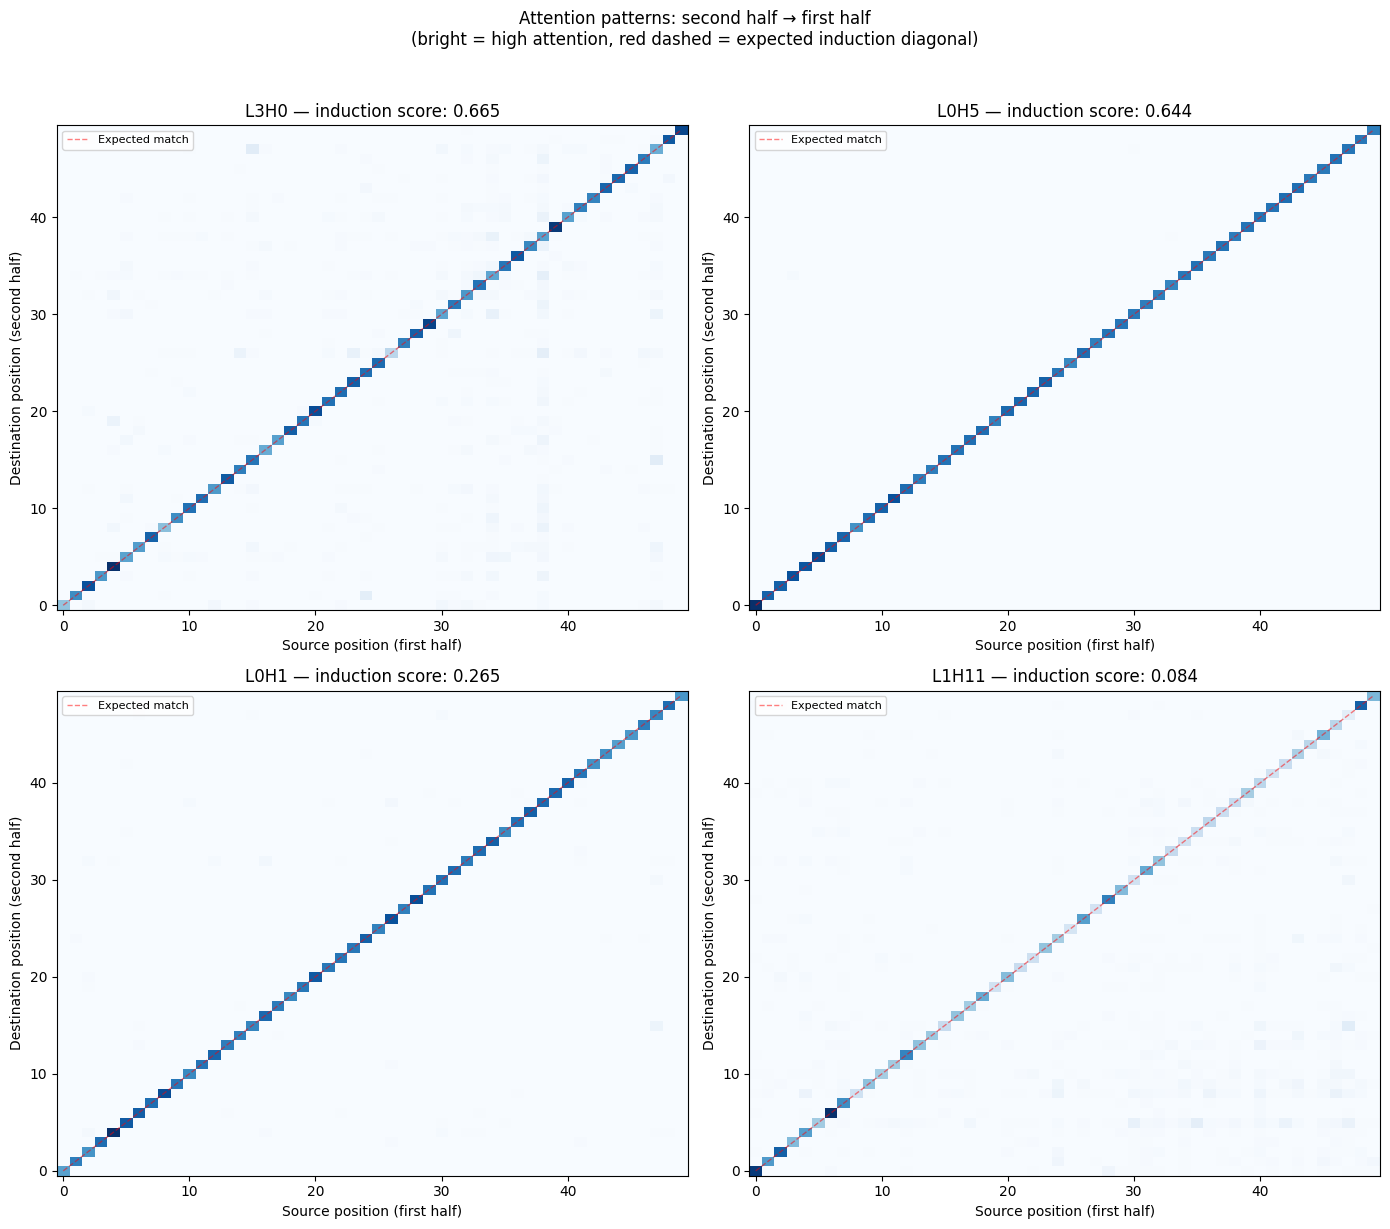

In [6]:
# Pick top 4 heads by induction score
top_induction_heads = []
flat_idx = induction_scores.flatten().argsort(descending=True)[:4]
for idx in flat_idx:
    layer = idx.item() // n_heads
    head = idx.item() % n_heads
    top_induction_heads.append((layer, head))

print('Plotting attention patterns for:', [f'L{l}H{h}' for l, h in top_induction_heads])

# Use first example in the batch
example_idx = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (layer, head) in zip(axes.flatten(), top_induction_heads):
    attn = cache[f'blocks.{layer}.attn.hook_pattern']
    pattern = attn[example_idx, head].cpu().numpy()  # [dest, src]

    # Show only second-half destinations attending to first-half sources
    # dest: positions N_CTX_HALF+1 to end (second half)
    # src: positions 1 to N_CTX_HALF (first half)
    second_half_dest = pattern[1 + N_CTX_HALF:, 1:1 + N_CTX_HALF]

    im = ax.imshow(second_half_dest, aspect='auto', cmap='Blues', origin='lower')
    ax.set_xlabel('Source position (first half)')
    ax.set_ylabel('Destination position (second half)')
    ax.set_title(f'L{layer}H{head} — induction score: {induction_scores[layer, head]:.3f}')

    # Draw the expected diagonal (matching positions)
    diag_x = np.arange(min(second_half_dest.shape))
    ax.plot(diag_x, diag_x, 'r--', alpha=0.5, linewidth=1, label='Expected match')
    ax.legend(fontsize=8)

plt.suptitle('Attention patterns: second half → first half\n(bright = high attention, red dashed = expected induction diagonal)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/fig4c_attention_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## What we learned

1. **Induction scores** identify which heads attend to the matching position
2. **Scatter plot** confirms: heads with high induction scores are the same heads
   that are causally important (high ablation contribution)
3. **Attention heatmaps** show the characteristic diagonal pattern — visual proof
   that these heads are implementing the "look back and copy" algorithm

This closes the loop: the heads we identified via patching and ablation are
genuinely performing induction, not just correlated with it.